In [1]:
import numpy as np
import torch
from sbi.utils import BoxUniform
import matplotlib.pyplot as plt
from simulator import simulator

# Define prior bounds
prior = BoxUniform(
    low=torch.tensor([-9.0, 0.5, -4.0]),
    high=torch.tensor([-4.0, 15.0, -1.0])
)


In [2]:
theta = prior.sample((2,)).squeeze().numpy()
x = simulator(theta[0], reps=1)
x.shape

torch.Size([1, 11])

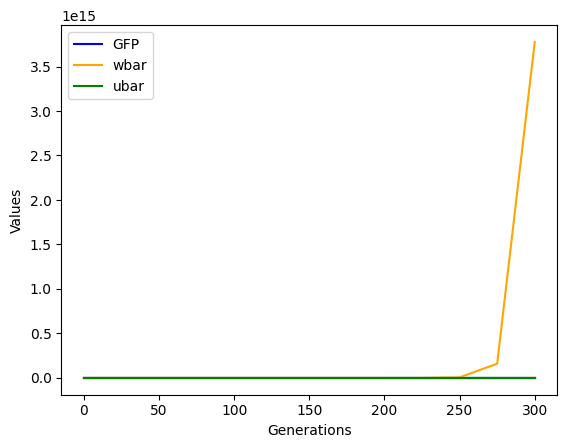

In [3]:
# Example usage:
theta = prior.sample((2,)).squeeze().numpy()

for i in range(theta.shape[0]):
    summary, batch = simulator(theta[i], reps=1, return_raw=True)
    gens = np.arange(0, 301, 25)
    GFP, wbar, ubar = np.split(batch.T, 3)
    plt.plot(gens, GFP, label='GFP' if i == 0 else "", color='blue')
    plt.plot(gens, wbar, label='wbar' if i == 0 else "", color='orange')
    plt.plot(gens, ubar, label='ubar' if i == 0 else "", color='green')
    plt.xlabel('Generations')
    plt.ylabel('Values')
    plt.legend()

In [8]:
# sbi imports
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

# Sample 500,000 parameter sets
num_samples = 10_000

# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

# Check simulator, returns PyTorch simulator able to simulate batches.
sbi_simulator = process_simulator(simulator, prior, prior_returns_numpy)

# Consistency check after making ready for sbi.
check_sbi_inputs(sbi_simulator, prior)

# Generate training data
theta, x = simulate_for_sbi(sbi_simulator, proposal=prior, num_simulations=num_samples, num_workers=80)

torch.save(theta, "train_theta.pt")
torch.save(x, "train_x.pt")

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
# Load saved data
train_theta = torch.load("train_theta.pt")
train_x = torch.load("train_x.pt").squeeze(1)  # shape: (num_samples, reps, features) or (num_samples, features) if reps squeezed


# Train NPE
inference = NPE(prior=prior)
density_estimator = inference.append_simulations(train_theta, train_x).train()
posterior = inference.build_posterior(density_estimator)

# Save the posterior model
import pickle
with open("posterior_singles.pkl", "wb") as f:
    pickle.dump(posterior, f)

 Training neural network. Epochs trained: 23

In [4]:
# load the posterior model
import pickle
with open("posterior_singles.pkl", "rb") as f:
    posterior = pickle.load(f)
# load NPE+PIE posterior
# with open("posterior_iid_200k.pkl", "rb") as f:
#     posterior_pie = pickle.load(f)

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

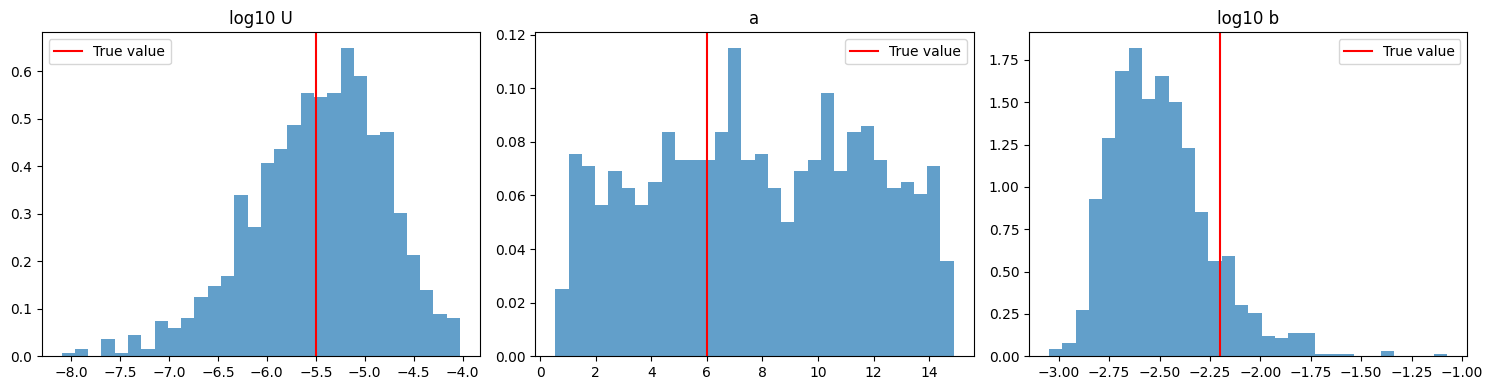

In [5]:
theta = torch.tensor([-5.5,6,-2.2])  # Example parameters in log10 space
samples = posterior.set_default_x(simulator(theta, reps=1)).sample((1000,))
param_names = ["log10 U", "a", "log10 b"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.hist(samples[:, i].numpy(), bins=30, density=True, alpha=0.7)
    ax.axvline(theta[i], color='red', label='True value')
    ax.set_title(param_names[i])
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import sys
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from seaborn import kdeplot

x = simulator(theta, reps=10)
# x = x + torch.randn_like(x) * 0.01  # Add some noise to the observations
op = CollectivePosterior(prior, x, posterior, 1, -100000)
op.get_log_C()
samps = op.sample(1000)

# samps_pie = posterior_pie.set_default_x(x).sample((1000,))

param_names = ["log10 U", "a", "log10 b"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    kdeplot(samples[:, i].numpy(), fill=True, alpha=0.5, label='Posterior', ax=ax)
    kdeplot(samps[:, i].numpy(), fill=True, alpha=0.5, label='Collective', ax=ax)
    # kdeplot(samps_pie[:, i].numpy(), fill=True, alpha=0.5, label='NPE+PIE', ax=ax)
    ax.axvline(theta[i], color='red', label='True value')
    ax.set_title(param_names[i])
    ax.legend()
plt.tight_layout()
plt.show()

Rejection Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]/home/jupyter-nadavbennun/Nadav/Posterior/collective_posterior/GORDO/../collective_posterior.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta, dtype=torch.float32)
Rejection Sampling: 1048it [00:00, 2081.28it/s]                         


NameError: name 'posterior_pie' is not defined